In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

2026-03-19 07:34:56.152374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773905696.347076      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773905696.401856      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773905696.891143      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773905696.891176      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773905696.891179      25 computation_placer.cc:177] computation placer alr

In [2]:
train_path = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/train'
val_path   = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/val'
test_path  = '/kaggle/input/datasets/adlinhedilisyam/test-deepfake/dataset_split/test'

In [3]:
from sklearn.utils.class_weight import compute_class_weight

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest'
)
val_gen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Class weights to handle imbalance
labels = train_data.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Classes     :", train_data.class_indices)
print("Class weights:", class_weight_dict)

Found 1428 images belonging to 2 classes.
Found 306 images belonging to 2 classes.
Found 307 images belonging to 2 classes.
Classes     : {'training_fake': 0, 'training_real': 1}
Class weights: {0: np.float64(1.0625), 1: np.float64(0.9444444444444444)}


In [4]:
from tensorflow.keras.layers import BatchNormalization

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)          
x = Dense(256, activation='relu')(x)  
x = Dense(128, activation='relu')(x)  
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-3),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1773905719.595186      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773905719.601049      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,153,473 (92.14 MB)

 Trainable params: 561,665 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1)
]

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,                        
    class_weight=class_weight_dict,   
    callbacks=callbacks
)
print(f"Phase 1 best val_accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1773905731.950922      92 service.cc:152] XLA service 0x7a29f40526c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773905731.950962      92 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773905731.950968      92 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773905733.900650      92 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/45 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3594 - loss: 1.1171  

I0000 00:00:1773905739.086617      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.4947 - loss: 0.9126 - val_accuracy: 0.5784 - val_loss: 0.6693 - learning_rate: 0.0010
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 679ms/step - accuracy: 0.6275 - loss: 0.6670 - val_accuracy: 0.6144 - val_loss: 0.6481 - learning_rate: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 652ms/step - accuracy: 0.6416 - loss: 0.6561 - val_accuracy: 0.6438 - val_loss: 0.6324 - learning_rate: 0.0010
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 687ms/step - accuracy: 0.6971 - loss: 0.5637 - val_accuracy: 0.6471 - val_loss: 0.6254 - learning_rate: 0.0010
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 647ms/step - accuracy: 0.7104 - loss: 0.5451 - val_accuracy: 0.6830 - val_loss: 0.6172 - learning_rate: 0.0010
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 704ms/step - accuracy: 0.7553 - loss: 0.4976 - val_accuracy: 0.6732 - val_loss: 0.6354 - learning_rate: 0.0010
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 32s 705ms/step - accuracy: 0.7447 - loss: 0.4877 - val_acc

In [6]:
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-30:]:   
    layer.trainable = True

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers: {trainable} / {len(model.layers)}")

Trainable layers: 36 / 181


In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history2 = model.fit(              
    train_data,
    validation_data=val_data,
    epochs=45,                       
    class_weight=class_weight_dict,   
    callbacks=callbacks
)
print(f"Phase 2 best val_accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

Epoch 1/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 60s 917ms/step - accuracy: 0.7331 - loss: 0.5324 - val_accuracy: 0.6471 - val_loss: 0.6298 - learning_rate: 1.0000e-05
Epoch 2/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 657ms/step - accuracy: 0.7654 - loss: 0.4855 - val_accuracy: 0.6438 - val_loss: 0.6366 - learning_rate: 1.0000e-05
Epoch 3/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 670ms/step - accuracy: 0.7610 - loss: 0.4651 - val_accuracy: 0.6438 - val_loss: 0.6394 - learning_rate: 1.0000e-05
Epoch 4/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 679ms/step - accuracy: 0.7671 - loss: 0.4935 - val_accuracy: 0.6601 - val_loss: 0.6446 - learning_rate: 1.0000e-05
Epoch 5/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8038 - loss: 0.4525
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 672ms/step - accuracy: 0.8036 - loss: 0.4527 - val_accuracy: 0.6634 - val_loss: 0.6539 - learning_rate: 1.0000e-05
Epoch 6/45
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 663ms/step - accuracy:

In [9]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 782ms/step - accuracy: 0.6478 - loss: 0.8076
Test Accuracy: 0.6449511647224426


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 615ms/step


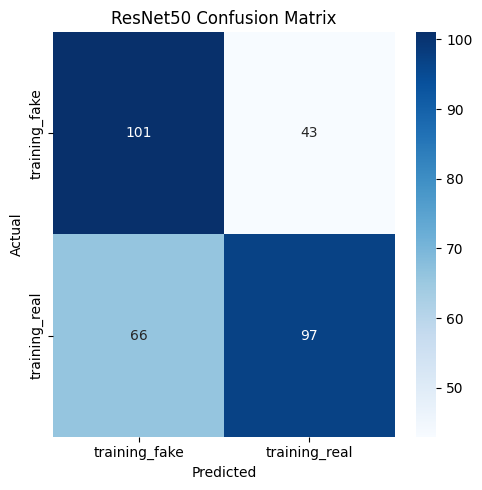

In [10]:
test_data.reset()
y_pred_prob = model.predict(test_data)
y_pred_classes = (y_pred_prob > 0.5).astype(int).ravel()
y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet50 Confusion Matrix')
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

               precision    recall  f1-score   support

training_fake       0.60      0.70      0.65       144
training_real       0.69      0.60      0.64       163

     accuracy                           0.64       307
    macro avg       0.65      0.65      0.64       307
 weighted avg       0.65      0.64      0.64       307



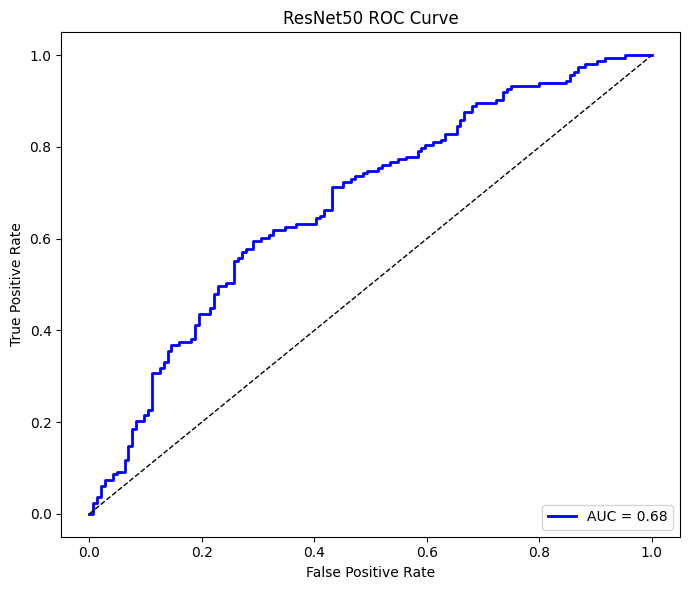

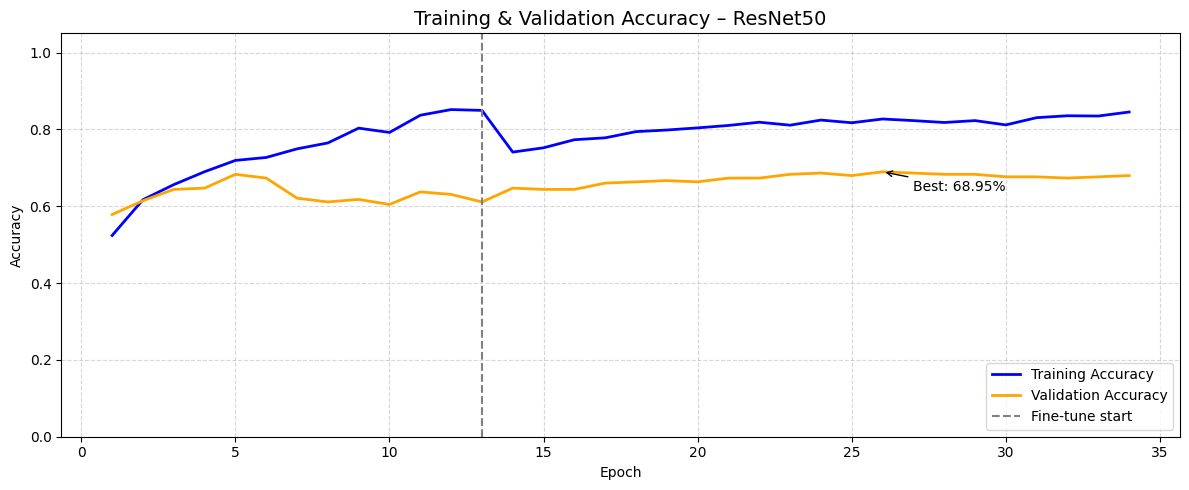

Best Training Accuracy  : 85.15%
Best Validation Accuracy: 68.95%
Achieved at Epoch       : 26


In [ ]:
# ROC Curve 
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet50 ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Accuracy Line Chart 
acc   = history1.history['accuracy']     + history2.history['accuracy']
vacc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
phase2_start = len(history1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

best_val_epoch = int(np.argmax(vacc)) + 1
best_val_acc   = max(vacc)

plt.figure(figsize=(12, 5))
plt.plot(epochs_range, acc,  label='Training Accuracy',   color='blue',   linewidth=2)
plt.plot(epochs_range, vacc, label='Validation Accuracy', color='orange', linewidth=2)
plt.axvline(x=phase2_start, color='grey', linestyle='--', linewidth=1.5, label='Fine-tune start')
plt.annotate(
    f'Best: {best_val_acc*100:.2f}%',
    xy=(best_val_epoch, best_val_acc),
    xytext=(best_val_epoch + 1, best_val_acc - 0.05),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)
plt.title('Training & Validation Accuracy – ResNet50', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1.05])
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Best Training Accuracy  : {max(acc)*100:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Achieved at Epoch       : {best_val_epoch}")

In [13]:
model.save("deepfake_resnet_model.keras")